# 06 · Topographic organization metric

A *type* of metric that scores a model's spatial unit layout against cortical topography (TDANN / TopoLM), via the correlation-vs-distance profile — not predictivity.

This notebook is laptop-safe: it uses synthetic smooth and random response maps. Real fMRI surface coordinates belong in the EC2 benchmark run.


In [1]:
import warnings
warnings.filterwarnings('ignore', message='xarray subclass Score should explicitly define __slots__', category=FutureWarning)

import numpy as np
from scipy.ndimage import gaussian_filter
from brainscore.metrics.topographic import (spatial_smoothness,
    correlation_distance_profile, topographic_alignment)
def grid_pos(g):
    r,c=np.meshgrid(np.arange(g),np.arange(g),indexing='ij')
    return np.stack([r.ravel(),c.ravel()],-1)/(g-1)
def topo(n=60,g=16,seed=0,sig=2.0):
    rng=np.random.RandomState(seed); pos=grid_pos(g)
    R=np.stack([gaussian_filter(rng.randn(g,g),sig,mode='wrap').ravel() for _ in range(n)])
    return R,pos
def rand(n=60,g=16,seed=0):
    rng=np.random.RandomState(seed); return rng.randn(n,g*g),grid_pos(g)

## Topographic model has high spatial smoothness; random ~0

In [2]:
tr,tp=topo(); rr,rp=rand()
print('topographic smoothness:', round(spatial_smoothness(tr,tp),3))
print('random smoothness:     ', round(spatial_smoothness(rr,rp),3))

topographic smoothness: 0.402
random smoothness:      -0.004


## Correlation-vs-distance profile (the descriptor)

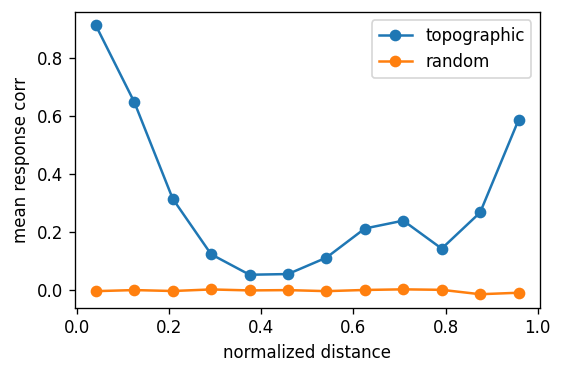

topographic profile starts above random: True
wrote plot: /var/folders/h6/g53mxg516n538136hh74630r0000gn/T/topo_profile_demo.png


In [3]:
from pathlib import Path
import tempfile
from IPython.display import Image, display
import matplotlib.pyplot as plt

cx, cy, _ = correlation_distance_profile(tr, tp, n_bins=12)
rx, ry, _ = correlation_distance_profile(rr, rp, n_bins=12)
plt.figure(figsize=(5, 3.2))
plt.plot(cx, cy, '-o', label='topographic')
plt.plot(rx, ry, '-o', label='random')
plt.xlabel('normalized distance')
plt.ylabel('mean response corr')
plt.legend()
out_png = Path(tempfile.gettempdir()) / 'topo_profile_demo.png'
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.close()
display(Image(str(out_png)))
print('topographic profile starts above random:', bool(cy[0] > ry[0]))
print('wrote plot:', out_png)


On fMRI, the brain's profile is computed from voxel surface coordinates and `TopographicMetric` correlates the two profiles — high when the model is organized like cortex.